In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

**Loading-DDRNet23Slim**

In [2]:
!git clone https://github.com/ydhongHIT/DDRNet.git

Cloning into 'DDRNet'...
remote: Enumerating objects: 260, done.
remote: Counting objects: 100% (260/260), done.
remote: Compressing objects: 100% (119/119), done.
remote: Total 260 (delta 161), reused 223 (delta 137), pack-reused 0 (from 0)
Receiving objects: 100% (260/260), 282.61 KiB | 2.52 MiB/s, done.
Resolving deltas: 100% (161/161), done.


In [3]:
import sys

sys.path.append("/kaggle/working/DDRNet/segmentation")

In [4]:
import os

print(os.path.exists("/kaggle/working/DDRNet"))

True


In [5]:
import os

for root, dirs, files in os.walk("/kaggle/working/DDRNet"):
    print(root)
    for f in files:
        print("   ", f)

/kaggle/working/DDRNet
    README.md
    LICENSE
/kaggle/working/DDRNet/segmentation
    DDRNet_23_slim_eval_speed.py
    DDRNet_seg
    DDRNet_23.py
    DDRNet_23_slim.py
    DDRNet_39.py
/kaggle/working/DDRNet/.git
    config
    index
    HEAD
    description
    packed-refs
/kaggle/working/DDRNet/.git/branches
/kaggle/working/DDRNet/.git/refs
/kaggle/working/DDRNet/.git/refs/heads
    main
/kaggle/working/DDRNet/.git/refs/remotes
/kaggle/working/DDRNet/.git/refs/remotes/origin
    HEAD
/kaggle/working/DDRNet/.git/refs/tags
/kaggle/working/DDRNet/.git/hooks
    pre-push.sample
    pre-rebase.sample
    pre-receive.sample
    applypatch-msg.sample
    pre-merge-commit.sample
    post-update.sample
    update.sample
    pre-applypatch.sample
    pre-commit.sample
    prepare-commit-msg.sample
    push-to-checkout.sample
    fsmonitor-watchman.sample
    commit-msg.sample
/kaggle/working/DDRNet/.git/objects
/kaggle/working/DDRNet/.git/objects/pack
    pack-57320a41a87404e8a6e244e1b8265

In [6]:
import sys

sys.path.append("/kaggle/working/DDRNet/segmentation")

In [7]:
from DDRNet_23_slim import DualResNet

In [8]:
import inspect

print(inspect.signature(DualResNet))

(block, layers, num_classes=19, planes=64, spp_planes=128, head_planes=128, augment=False)


In [9]:
import inspect
import DDRNet_23_slim

print(inspect.getsource(DDRNet_23_slim)[-1500:])

lf.layer4(self.relu(x))
        layers.append(x)
        x_ = self.layer4_(self.relu(x_))

        x = x + self.down4(self.relu(x_))
        x_ = x_ + F.interpolate(
                        self.compression4(self.relu(layers[3])),
                        size=[height_output, width_output],
                        mode='bilinear')

        x_ = self.layer5_(self.relu(x_))
        x = F.interpolate(
                        self.spp(self.layer5(self.relu(x))),
                        size=[height_output, width_output],
                        mode='bilinear')

        x_ = self.final_layer(x + x_)

        if self.augment: 
            x_extra = self.seghead_extra(temp)
            return [x_, x_extra]
        else:
            return x_      

def DualResNet_imagenet(pretrained=False):
    model = DualResNet(BasicBlock, [2, 2, 2, 2], num_classes=19, planes=32, spp_planes=128, head_planes=64, augment=False)
    if pretrained:
        checkpoint = torch.load('/home/user1/hyd/HRNet/' + "DDR

In [10]:
import sys
sys.path.append("/kaggle/working/DDRNet/segmentation")

from DDRNet_23_slim import get_seg_model

In [11]:
model=get_seg_model(cfg=None)

In [12]:
model = get_seg_model(cfg=None,num_classes=2)

In [13]:
import torch

x = torch.randn(2,3,512,512)

with torch.no_grad():
    y = model(x)

print(y.shape)

torch.Size([2, 19, 64, 64])


In [14]:
from DDRNet_23_slim import DualResNet, BasicBlock

model = DualResNet(
    BasicBlock,
    layers=[2, 2, 2, 2],
    num_classes=2,
    planes=32,
    spp_planes=128,
    head_planes=64,
    augment=False
)

In [15]:
import torch

checkpoint = torch.load(
    "/kaggle/input/datasets/aseedfaisal/ddrnet23-baseline/DDRNet23s_imagenet.pth",
    map_location="cpu"
)

In [16]:
print(type(checkpoint))

if isinstance(checkpoint, dict):
    print(checkpoint.keys())

<class 'collections.OrderedDict'>
odict_keys(['conv1.0.weight', 'conv1.0.bias', 'conv1.1.weight', 'conv1.1.bias', 'conv1.1.running_mean', 'conv1.1.running_var', 'conv1.1.num_batches_tracked', 'conv1.3.weight', 'conv1.3.bias', 'conv1.4.weight', 'conv1.4.bias', 'conv1.4.running_mean', 'conv1.4.running_var', 'conv1.4.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.bn1.num_batches_tracked', 'layer1.1.conv2.weight', 'layer1.1.bn2.weight', 'layer1.1.bn2.bias', 'layer1.1.bn2.running_mean', 'layer1.1.bn2.running_var', 'layer1.1.bn2.num_batches_tracked', 'layer2.0.conv

In [17]:
state_dict = checkpoint

In [18]:
missing, unexpected = model.load_state_dict(
    state_dict,
    strict=False
)

print("Missing:", missing)
print("Unexpected:", unexpected)

Missing: ['spp.scale1.1.weight', 'spp.scale1.1.bias', 'spp.scale1.1.running_mean', 'spp.scale1.1.running_var', 'spp.scale1.3.weight', 'spp.scale2.1.weight', 'spp.scale2.1.bias', 'spp.scale2.1.running_mean', 'spp.scale2.1.running_var', 'spp.scale2.3.weight', 'spp.scale3.1.weight', 'spp.scale3.1.bias', 'spp.scale3.1.running_mean', 'spp.scale3.1.running_var', 'spp.scale3.3.weight', 'spp.scale4.1.weight', 'spp.scale4.1.bias', 'spp.scale4.1.running_mean', 'spp.scale4.1.running_var', 'spp.scale4.3.weight', 'spp.scale0.0.weight', 'spp.scale0.0.bias', 'spp.scale0.0.running_mean', 'spp.scale0.0.running_var', 'spp.scale0.2.weight', 'spp.process1.0.weight', 'spp.process1.0.bias', 'spp.process1.0.running_mean', 'spp.process1.0.running_var', 'spp.process1.2.weight', 'spp.process2.0.weight', 'spp.process2.0.bias', 'spp.process2.0.running_mean', 'spp.process2.0.running_var', 'spp.process2.2.weight', 'spp.process3.0.weight', 'spp.process3.0.bias', 'spp.process3.0.running_mean', 'spp.process3.0.running

In [20]:
loaded = []
not_loaded = []

model_dict = model.state_dict()

for k in model_dict.keys():
    if k in state_dict:
        loaded.append(k)
    else:
        not_loaded.append(k)

print(f"Loaded layers: {len(loaded)}")
print(f"Missing layers: {len(not_loaded)}")
print("\nFirst 20 loaded layers:")
print(loaded[:20])

Loaded layers: 254
Missing layers: 79

First 20 loaded layers:
['conv1.0.weight', 'conv1.0.bias', 'conv1.1.weight', 'conv1.1.bias', 'conv1.1.running_mean', 'conv1.1.running_var', 'conv1.1.num_batches_tracked', 'conv1.3.weight', 'conv1.3.bias', 'conv1.4.weight', 'conv1.4.bias', 'conv1.4.running_mean', 'conv1.4.running_var', 'conv1.4.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked']


In [21]:
model.eval()

with torch.no_grad():
    x = torch.randn(1, 3, 512, 512)
    y = model(x)

print(y.shape)

torch.Size([1, 2, 64, 64])


In [22]:
import torch
import torch.nn.functional as F

# --- 1. Build model ---
from DDRNet_23_slim import DualResNet, BasicBlock

model = DualResNet(BasicBlock, [2, 2, 2, 2], num_classes=2,
                    planes=32, spp_planes=128, head_planes=64, augment=False)

# --- 2. Load pretrained backbone, verify only expected layers differ ---
checkpoint = torch.load("/kaggle/input/datasets/aseedfaisal/ddrnet23-baseline/DDRNet23s_imagenet.pth", map_location="cpu")
missing, unexpected = model.load_state_dict(checkpoint, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

# Missing = segmentation-only modules (SPP, final head) absent from an ImageNet checkpoint — expected
allowed_missing = ("spp.", "final_layer.", "seghead_extra.")
# Unexpected = ImageNet classification head (pooling/linear) absent from the seg model — expected
allowed_unexpected = ("down5.", "last_layer.", "linear.")

bad_missing = [k for k in missing if not k.startswith(allowed_missing)]
bad_unexpected = [k for k in unexpected if not k.startswith(allowed_unexpected)]

assert not bad_missing, f"Backbone layers failed to load: {bad_missing}"
assert not bad_unexpected, f"Unexpected checkpoint keys outside classifier head: {bad_unexpected}"
print(" Backbone loaded correctly, only head/classifier layers differ as expected\n")

# --- 3. Forward pass on dummy input, check output shape ---
model.eval()
crop_size = 1024  # match your actual training crop size
x = torch.randn(2, 3, crop_size, crop_size)
with torch.no_grad():
    out = model(x)

print("Output shape:", out.shape)
assert out.shape[0] == 2 and out.shape[1] == 2, f"Unexpected channel/batch dims: {out.shape}"
assert not torch.isnan(out).any(), "NaNs in output — check weight loading"
print(f"Output spatial size: {out.shape[-2:]} vs input {x.shape[-2:]} "
      f"(stride {crop_size // out.shape[-1]})\n")

# --- 4. Gradient flow check (catches frozen/disconnected layers) ---
model.train()
x = torch.randn(2, 3, 512, 512)
target = torch.randint(0, 2, (2, 512, 512))

out = model(x)
if out.shape[-2:] != target.shape[-2:]:
    out_up = F.interpolate(out, size=target.shape[-2:], mode='bilinear', align_corners=False)
else:
    out_up = out

loss = F.cross_entropy(out_up, target)
loss.backward()

no_grad_params = [n for n, p in model.named_parameters() if p.requires_grad and p.grad is None]
print("Params with no gradient:", no_grad_params)
assert len(no_grad_params) == 0, "Some params never got a gradient — check forward graph"

# --- 5. Param count sanity ---
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n Sanity check passed.")
print(f"Loss: {loss.item():.4f}")
print(f"Total params: {total_params/1e6:.2f}M | Trainable: {trainable_params/1e6:.2f}M")

Missing keys: ['spp.scale1.1.weight', 'spp.scale1.1.bias', 'spp.scale1.1.running_mean', 'spp.scale1.1.running_var', 'spp.scale1.3.weight', 'spp.scale2.1.weight', 'spp.scale2.1.bias', 'spp.scale2.1.running_mean', 'spp.scale2.1.running_var', 'spp.scale2.3.weight', 'spp.scale3.1.weight', 'spp.scale3.1.bias', 'spp.scale3.1.running_mean', 'spp.scale3.1.running_var', 'spp.scale3.3.weight', 'spp.scale4.1.weight', 'spp.scale4.1.bias', 'spp.scale4.1.running_mean', 'spp.scale4.1.running_var', 'spp.scale4.3.weight', 'spp.scale0.0.weight', 'spp.scale0.0.bias', 'spp.scale0.0.running_mean', 'spp.scale0.0.running_var', 'spp.scale0.2.weight', 'spp.process1.0.weight', 'spp.process1.0.bias', 'spp.process1.0.running_mean', 'spp.process1.0.running_var', 'spp.process1.2.weight', 'spp.process2.0.weight', 'spp.process2.0.bias', 'spp.process2.0.running_mean', 'spp.process2.0.running_var', 'spp.process2.2.weight', 'spp.process3.0.weight', 'spp.process3.0.bias', 'spp.process3.0.running_mean', 'spp.process3.0.ru

**PreTraining(Massachusetts+DeepGlobe)**

In [42]:
import os

def explore(path, max_depth=3, max_files=5):
    for root, dirs, files in os.walk(path):
        depth = root[len(path):].count(os.sep)
        if depth > max_depth:
            dirs[:] = []
            continue
        indent = "  " * depth
        print(f"{indent}{root}/")
        for f in sorted(files)[:max_files]:
            fpath = os.path.join(root, f)
            size = os.path.getsize(fpath)
            print(f"{indent}  {f}  ({size/1024:.1f} KB)")
        if len(files) > max_files:
            print(f"{indent}  ... +{len(files) - max_files} more files")

print("=== Massachusetts Roads ===")
explore("/kaggle/input/datasets/balraj98/massachusetts-roads-dataset")  # adjust slug if different

print("\n=== DeepGlobe ===")
explore("/kaggle/input/datasets/balraj98/deepglobe-road-extraction-dataset")  # adjust slug if different

=== Massachusetts Roads ===
/kaggle/input/datasets/balraj98/massachusetts-roads-dataset/
  label_class_dict.csv  (0.0 KB)
  metadata.csv  (332.4 KB)
  /kaggle/input/datasets/balraj98/massachusetts-roads-dataset/tiff/
    /kaggle/input/datasets/balraj98/massachusetts-roads-dataset/tiff/val_labels/
      10228690_15.tif  (2197.4 KB)
      10978735_15.tif  (2197.4 KB)
      10978795_15.tif  (2197.4 KB)
      18028945_15.tif  (2197.4 KB)
      21929020_15.tif  (2197.4 KB)
      ... +9 more files
    /kaggle/input/datasets/balraj98/massachusetts-roads-dataset/tiff/test_labels/
      10378780_15.tif  (2197.4 KB)
      10828720_15.tif  (2197.4 KB)
      11128870_15.tif  (2197.4 KB)
      11278840_15.tif  (2197.4 KB)
      11728825_15.tif  (2197.4 KB)
      ... +44 more files
    /kaggle/input/datasets/balraj98/massachusetts-roads-dataset/tiff/val/
      10228690_15.tiff  (6607.3 KB)
      10978735_15.tiff  (6607.3 KB)
      10978795_15.tiff  (6607.3 KB)
      18028945_15.tiff  (6607.3 KB)
   

In [25]:
import numpy as np
from PIL import Image

# Check Massachusetts mask encoding
mass_mask = np.array(Image.open("/kaggle/input/datasets/balraj98/massachusetts-roads-dataset/tiff/train_labels/10078660_15.tif"))
print("Mass mask shape:", mass_mask.shape, "| dtype:", mass_mask.dtype, "| unique values:", np.unique(mass_mask))

# Check DeepGlobe mask encoding
dg_mask = np.array(Image.open("/kaggle/input/datasets/balraj98/deepglobe-road-extraction-dataset/train/100034_mask.png"))
print("DeepGlobe mask shape:", dg_mask.shape, "| dtype:", dg_mask.dtype, "| unique values:", np.unique(dg_mask))

Mass mask shape: (1500, 1500) | dtype: uint8 | unique values: [  0 255]
DeepGlobe mask shape: (1024, 1024, 3) | dtype: uint8 | unique values: [  0 255]


In [26]:
import shutil
from pathlib import Path

OUT_DIR = Path("/kaggle/working/pretrain_data")

if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
    print(f"Removed {OUT_DIR}")
else:
    print(f"{OUT_DIR} doesn't exist, nothing to clear")

/kaggle/working/pretrain_data doesn't exist, nothing to clear


In [27]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from pathlib import Path
from multiprocessing import Pool
from functools import partial
from tqdm import tqdm

TARGET_SIZE = 1024
OUT_DIR = Path("/kaggle/working/pretrain_data")
JPEG_QUALITY = 95

def binarize_mask(mask_arr, threshold=127):
    if mask_arr.ndim == 3:
        mask_arr = mask_arr.mean(axis=2)
    return ((mask_arr > threshold).astype(np.uint8)) * 255

def process_pair(args):
    img_path, mask_path, out_name, split = args
    try:
        img = Image.open(img_path).convert("RGB").resize((TARGET_SIZE, TARGET_SIZE), Image.BICUBIC)
        mask_arr = np.array(Image.open(mask_path))
        mask_bin = binarize_mask(mask_arr)
        mask_img = Image.fromarray(mask_bin).resize((TARGET_SIZE, TARGET_SIZE), Image.NEAREST)

        img.save(OUT_DIR / split / "images" / f"{out_name}.jpg", quality=JPEG_QUALITY)
        mask_img.save(OUT_DIR / split / "masks" / f"{out_name}.png")
        return None
    except Exception as e:
        return f"{out_name}: {e}"

if __name__ == "__main__":
    for split in ["train", "val"]:
        (OUT_DIR / split / "images").mkdir(parents=True, exist_ok=True)
        (OUT_DIR / split / "masks").mkdir(parents=True, exist_ok=True)

    MASS_ROOT = Path("/kaggle/input/datasets/balraj98/massachusetts-roads-dataset/tiff")
    DG_ROOT = Path("/kaggle/input/datasets/balraj98/deepglobe-road-extraction-dataset")

    tasks = []
    manifest_rows = []

    for split_in, split_out in [("train", "train"), ("val", "val")]:
        img_dir = MASS_ROOT / split_in
        mask_dir = MASS_ROOT / f"{split_in}_labels"
        for img_file in sorted(os.listdir(img_dir)):
            stem = Path(img_file).stem
            mask_path = mask_dir / f"{stem}.tif"
            if not mask_path.exists():
                continue
            out_name = f"mass_{stem}"
            tasks.append((img_dir / img_file, mask_path, out_name, split_out))
            manifest_rows.append({"name": out_name, "source": "massachusetts", "split": split_out})

    dg_train_dir = DG_ROOT / "train"
    dg_stems = sorted(set(f.split("_sat.jpg")[0] for f in os.listdir(dg_train_dir) if f.endswith("_sat.jpg")))
    dg_stems = [s for s in dg_stems if (dg_train_dir / f"{s}_mask.png").exists()]
    dg_train_stems, dg_val_stems = train_test_split(dg_stems, test_size=0.1, random_state=42)

    for stems, split_out in [(dg_train_stems, "train"), (dg_val_stems, "val")]:
        for stem in stems:
            out_name = f"deepglobe_{stem}"
            tasks.append((dg_train_dir / f"{stem}_sat.jpg", dg_train_dir / f"{stem}_mask.png", out_name, split_out))
            manifest_rows.append({"name": out_name, "source": "deepglobe", "split": split_out})

    print(f"Processing {len(tasks)} pairs with multiprocessing...")
    with Pool(processes=4) as pool:
        errors = list(tqdm(pool.imap_unordered(process_pair, tasks, chunksize=16), total=len(tasks)))

    errors = [e for e in errors if e is not None]
    if errors:
        print(f"\n{len(errors)} errors:")
        for e in errors[:20]:
            print(" ", e)

    manifest = pd.DataFrame(manifest_rows)
    manifest.to_csv(OUT_DIR / "manifest.csv", index=False)
    print(manifest.groupby(["source", "split"]).size())

Processing 7348 pairs with multiprocessing...


100%|██████████| 7348/7348 [03:57<00:00, 30.92it/s]


source         split
deepglobe      train    5603
               val       623
massachusetts  train    1108
               val        14
dtype: int64


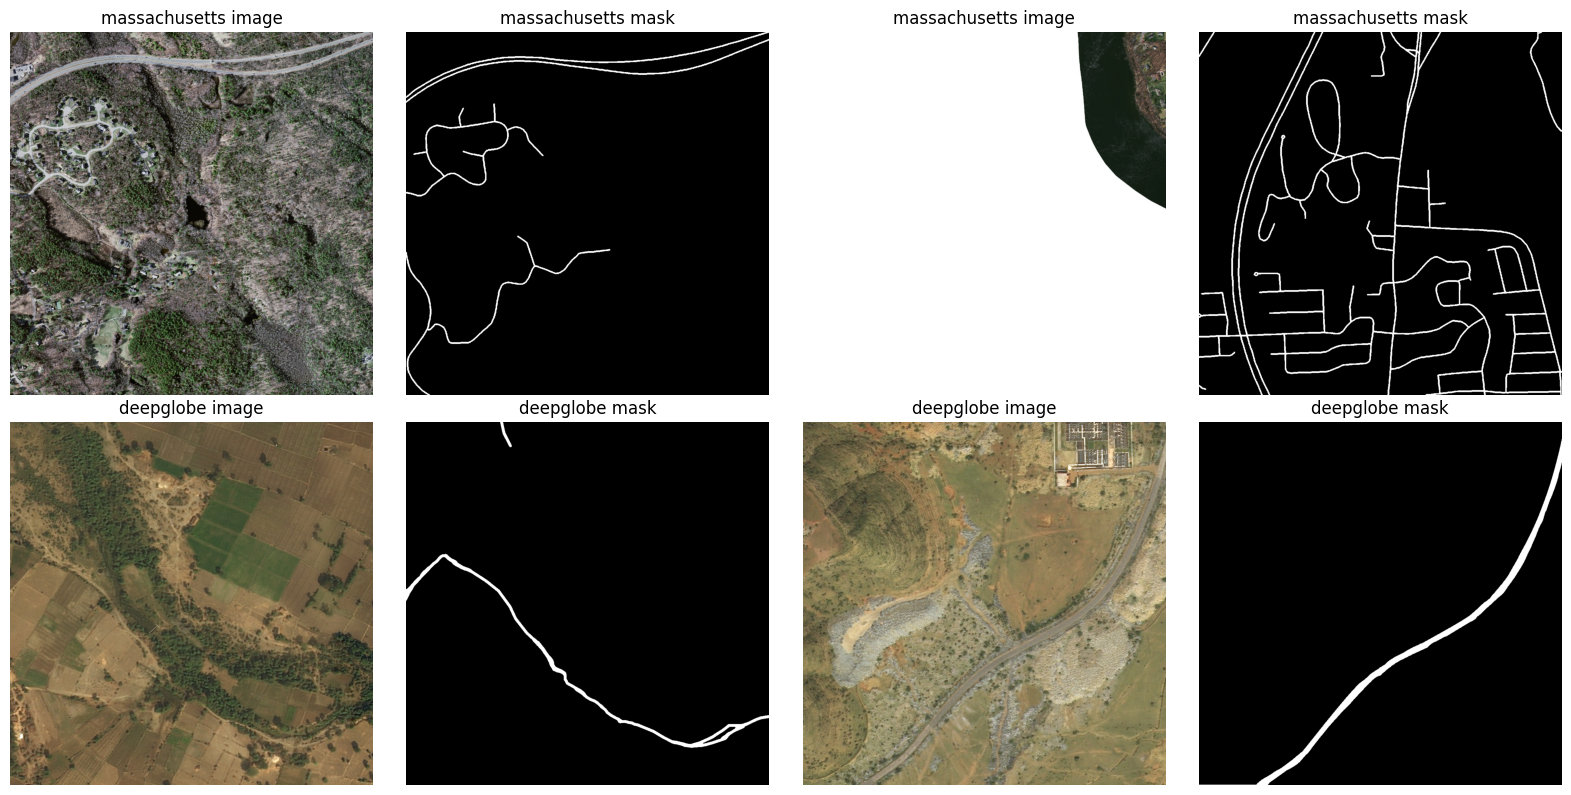

massachusetts mask unique values: [  0 255]
deepglobe mask unique values: [  0 255]


In [28]:
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

OUT_DIR = "/kaggle/working/pretrain_data"
manifest = pd.read_csv(f"{OUT_DIR}/manifest.csv")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, source in enumerate(["massachusetts", "deepglobe"]):
    samples = manifest[manifest.source == source].sample(2, random_state=1)
    for j, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(f"{OUT_DIR}/{row.split}/images/{row['name']}.jpg")
        mask = Image.open(f"{OUT_DIR}/{row.split}/masks/{row['name']}.png")
        axes[i, j*2].imshow(img)
        axes[i, j*2].set_title(f"{source} image")
        axes[i, j*2].axis("off")
        axes[i, j*2+1].imshow(mask, cmap="gray")
        axes[i, j*2+1].set_title(f"{source} mask")
        axes[i, j*2+1].axis("off")
plt.tight_layout()
plt.show()

# also confirm masks are actually binary, not something weird
import numpy as np
for source in ["massachusetts", "deepglobe"]:
    sample = manifest[manifest.source == source].iloc[0]
    mask = np.array(Image.open(f"{OUT_DIR}/{sample.split}/masks/{sample['name']}.png"))
    print(f"{source} mask unique values: {np.unique(mask)}")

**Pre Training Stage-1**

In [29]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image

OUT_DIR = "/kaggle/working/pretrain_data"
CROP_SIZE = 1024  # matches your model sanity check earlier; drop to 512/768 if VRAM-constrained

# ImageNet normalization — required since your backbone is ImageNet-pretrained,
# and it was trained expecting inputs normalized to these exact stats.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def get_train_transforms(crop_size=CROP_SIZE):
    return A.Compose([
        A.RandomCrop(crop_size, crop_size) if crop_size < 1024 else A.NoOp(),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=1.0),
        ], p=0.5),
        A.GaussNoise(std_range=(0.02, 0.08), p=0.2),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


def get_val_transforms(crop_size=CROP_SIZE):
    return A.Compose([
        A.CenterCrop(crop_size, crop_size) if crop_size < 1024 else A.NoOp(),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


class RoadSegDataset(Dataset):
    def __init__(self, manifest_df, out_dir, split, transform=None):
        self.df = manifest_df[manifest_df.split == split].reset_index(drop=True)
        self.out_dir = out_dir
        self.split = split
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = f"{self.out_dir}/{self.split}/images/{row['name']}.jpg"
        mask_path = f"{self.out_dir}/{self.split}/masks/{row['name']}.png"

        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path).convert("L"))
        mask = (mask > 127).astype(np.int64)  # {0,1} — not {0,255}, cross_entropy needs class indices

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"].long()

        return image, mask


def make_dataloaders(manifest_path, out_dir, source=None, crop_size=CROP_SIZE,
                      batch_size=8, num_workers=4):
    manifest = pd.read_csv(manifest_path)
    if source is not None:
        manifest = manifest[manifest.source == source].reset_index(drop=True)

    train_ds = RoadSegDataset(manifest, out_dir, "train", get_train_transforms(crop_size))
    val_ds = RoadSegDataset(manifest, out_dir, "val", get_val_transforms(crop_size))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                               num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader, train_ds, val_ds


# ============ Stage 1: Massachusetts only ============
train_loader_mass, val_loader_mass, train_ds_mass, val_ds_mass = make_dataloaders(
    f"{OUT_DIR}/manifest.csv", OUT_DIR, source="massachusetts", batch_size=8
)
print(f"Massachusetts — train: {len(train_ds_mass)}, val: {len(val_ds_mass)}")

# ============ Stage 2: DeepGlobe only ============
train_loader_dg, val_loader_dg, train_ds_dg, val_ds_dg = make_dataloaders(
    f"{OUT_DIR}/manifest.csv", OUT_DIR, source="deepglobe", batch_size=8
)
print(f"DeepGlobe — train: {len(train_ds_dg)}, val: {len(val_ds_dg)}")

Massachusetts — train: 1108, val: 14
DeepGlobe — train: 5603, val: 623


In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth=smooth

    def forward(self, logits, targets):
        probs=F.softmax(logits, dim=1)[:,1,:,:]
        targets=targets.float()
        intersection=(probs*targets).sum(dim=(1,2))
        union=probs.sum(dim=(1,2)) + targets.sum(dim=(1,2))
        dice=(2.0*intersection + self.smooth)/(union + self.smooth)
        return 1.0 - dice.mean()

class CombinedLoss(nn.Module) :
    def __init__(self, ce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.ce=nn.CrossEntropyLoss()
        self.dice=DiceLoss()
        self.ce_weight=ce_weight
        self.dice_weight=dice_weight

    def forward(self, logits, targets):
        ce_loss=self.ce(logits, targets)
        dice_loss=self.dice(logits, targets)
        return ce_loss*self.ce_weight + dice_loss*self.dice_weight,ce_loss, dice_loss
        



In [31]:
criterion = CombinedLoss()

dummy_logits = torch.randn(2, 2, 128, 128)
dummy_targets = torch.randint(0, 2, (2, 128, 128))

total, ce, dice = criterion(dummy_logits, dummy_targets)
print(f"Total: {total.item():.4f} | CE: {ce.item():.4f} | Dice: {dice.item():.4f}")

Total: 0.6973 | CE: 0.8972 | Dice: 0.4975


In [32]:
def build_optimizer(model, backbone_lr=1e-4, head_lr=1e-3, weight_decay=1e-4):
    backbone_params=[]
    head_params=[]
    for name, params in model.named_parameters():
        if name.startswith("spp.") or name.startswith("final_layer.") or name.startswith("seghead_extra."):
            head_params.append(params)
        else:
            backbone_params.append(params)

    optimizer=torch.optim.AdamW(
    [{"params": backbone_params, "lr": backbone_lr},
        {"params": head_params, "lr": head_lr},
    ], weight_decay=weight_decay)

    return optimizer

def build_scheduler(optimizer, num_epochs, steps_per_epoch, warmup_epochs=2):
    warmup_steps=warmup_epochs * steps_per_epoch
    total_steps=num_epochs * steps_per_epoch

    def lr_lambda(current_step):
        if current_step<warmup_steps:
            return current_step/max(1, warmup_steps)
        progress=(current_step-warmup_steps)/max(1,total_steps-warmup_steps)
        return 0.5 * (1.0 + torch.cos(torch.tensor(progress * 3.14159265)))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [33]:
optimizer = build_optimizer(model)

backbone_count = sum(p.numel() for g in optimizer.param_groups[:1] for p in g["params"])
head_count = sum(p.numel() for g in optimizer.param_groups[1:] for p in g["params"])
print(f"Backbone params: {backbone_count/1e6:.2f}M | Head params: {head_count/1e6:.2f}M")
print(f"Backbone LR: {optimizer.param_groups[0]['lr']} | Head LR: {optimizer.param_groups[1]['lr']}")

Backbone params: 4.55M | Head params: 1.15M
Backbone LR: 0.0001 | Head LR: 0.001


In [34]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, total_ce, total_dice=0.0, 0.0, 0.0
    pbar=tqdm(loader, desc="train")
    for images, masks in pbar:
        images, masks=images.to(device), masks.to(device)
        optimizer.zero_grad()
        logits=model(images)

        if logits.shape[-2:]!=masks.shape[-2:]:
            logits=F.interpolate(logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)

        loss, ce_loss, dice_loss=criterion(logits, masks)
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss+=loss.item()
        total_ce+=ce_loss.item()
        total_dice+=dice_loss.item()
        pbar.set_postfix(loss=loss.item())
    n=len(loader)
    return total_loss/n, total_ce/n, total_dice/n

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_intersection, total_union = 0.0, 0.0

    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        if logits.shape[-2:] != masks.shape[-2:]:
            logits = F.interpolate(logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)
        loss, _, _ = criterion(logits, masks)
        total_loss += loss.item()

        preds = logits.argmax(dim=1)
        total_intersection += ((preds == 1) & (masks == 1)).sum().item()
        total_union += ((preds == 1) | (masks == 1)).sum().item()

    val_loss = total_loss / len(loader)
    road_iou = total_intersection / (total_union + 1e-7)
    return val_loss, road_iou
print ("Functions are Ready")        

Functions are Ready


In [35]:
from torch.utils.data import TensorDataset, DataLoader

# ---- Fake dataset: mimics your real DataLoader's output shape exactly ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

dummy_images = torch.randn(8, 3, 1024, 1024)   # 8 fake samples, matches image tensor shape
dummy_masks = torch.randint(0, 2, (8, 1024, 1024))  # fake binary masks, full-res like your real masks

dummy_ds = TensorDataset(dummy_images, dummy_masks)
dummy_loader = DataLoader(dummy_ds, batch_size=2)  # 4 batches total

# ---- Dry pass ----
optimizer = build_optimizer(model)
scheduler = build_scheduler(optimizer, num_epochs=1, steps_per_epoch=len(dummy_loader))
criterion = CombinedLoss()

train_loss, train_ce, train_dice = train_one_epoch(model, dummy_loader, optimizer, scheduler, criterion, device)
print(f"\nTrain — loss: {train_loss:.4f} | CE: {train_ce:.4f} | Dice: {train_dice:.4f}")

val_loss, val_iou = validate(model, dummy_loader, criterion, device)
print(f"Val   — loss: {val_loss:.4f} | Road IoU: {val_iou:.4f}")

train: 100%|██████████| 4/4 [00:01<00:00,  2.63it/s, loss=1.53]



Train — loss: 1.5426 | CE: 2.4984 | Dice: 0.5868
Val   — loss: 0.7798 | Road IoU: 0.3002


In [36]:
import os

def run_training(model, train_loader, val_loader, num_epochs, device,
                backbone_lr=1e-4, head_lr=1e-3, checkpoint_dir="/kaggle/working/checkpoints",
                checkpoint_name="stage1_massachusetts"):
    os.makedirs(checkpoint_dir, exist_ok=True)
    optimizer=build_optimizer(model, backbone_lr=backbone_lr, head_lr=head_lr)
    scheduler=build_scheduler(optimizer, num_epochs=num_epochs, steps_per_epoch=len(train_loader))
    criterion=CombinedLoss()
    best_iou=0.0
    history=[]
    for epoch in range(num_epochs):
        print(f"\n=== Epoch {epoch+1}/{num_epochs} ===")
        train_loss, train_ce, train_dice=train_one_epoch(
            model, train_loader, optimizer, scheduler, criterion, device
        )
        val_loss, val_iou= validate(model, val_loader, criterion, device)
        print(f"Train loss: {train_loss:.4f} (CE: {train_ce:.4f}, Dice: {train_dice:.4f})")
        print(f"Val loss: {val_loss:.4f} | Val Road IoU: {val_iou:.4f}")
        history.append({
            "epoch": epoch + 1, "train_loss": train_loss, "train_ce": train_ce,
            "train_dice": train_dice, "val_loss": val_loss, "val_iou": val_iou
        })

        if val_iou > best_iou:
            best_iou = val_iou
            torch.save(model.state_dict(), f"{checkpoint_dir}/{checkpoint_name}_best.pth")
            print(f"New Best IoU ({val_iou:.4f}) - Check Point Saved ")
        torch.save(model.state_dict(), f"{checkpoint_dir}/{checkpoint_name}_last.pth")    
    return history

print("Training Pipeline Created successfully")

Training Pipeline Created successfully


In [37]:
import hashlib

@torch.no_grad()
def val_predictions_fingerprint(model, loader, device):
    model.eval()
    all_logits = []
    for images, masks in loader:
        images = images.to(device)
        logits = model(images)
        all_logits.append(logits.flatten().cpu())
    flat = torch.cat(all_logits)
    print("Sum:", flat.sum().item(), "| Mean:", flat.mean().item(), "| Std:", flat.std().item())
    print("Hash:", hashlib.md5(flat.numpy().tobytes()).hexdigest())

val_predictions_fingerprint(model, val_loader_mass, device)

Sum: -312131.03125 | Mean: -0.6803916692733765 | Std: 1.8304128646850586
Hash: 4b71930a6b3821d4dc5f87525185e96c


In [38]:
@torch.no_grad()
def validate_verbose(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_intersection, total_union = 0.0, 0.0
    total_road_pixels_pred, total_road_pixels_true = 0.0, 0.0

    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        if logits.shape[-2:] != masks.shape[-2:]:
            logits = F.interpolate(logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)
        loss, _, _ = criterion(logits, masks)
        total_loss += loss.item()

        preds = logits.argmax(dim=1)
        intersection = ((preds == 1) & (masks == 1)).sum().item()
        union = ((preds == 1) | (masks == 1)).sum().item()
        total_intersection += intersection
        total_union += union
        total_road_pixels_pred += (preds == 1).sum().item()
        total_road_pixels_true += (masks == 1).sum().item()

    print(f"Total intersection: {total_intersection}")
    print(f"Total union: {total_union}")
    print(f"Predicted road pixels: {total_road_pixels_pred}")
    print(f"True road pixels: {total_road_pixels_true}")
    print(f"IoU (raw): {total_intersection/(total_union+1e-7)}")
    print(f"Val loss: {total_loss/len(loader):.8f}")

validate_verbose(model, val_loader_mass, criterion, device)

Total intersection: 308236.0
Total union: 5312651.0
Predicted road pixels: 4608211.0
True road pixels: 1012676.0
IoU (raw): 0.058019245005929095
Val loss: 0.82244310


In [ ]:
from IPython.display import FileLink

FileLink("/kaggle/working/my_files.zip")

**PreTraining Stage-2**

In [ ]:
model_stage2=DualResNet(BasicBlock,[2,2,2,2],num_classes=2, 
                        planes=32, spp_planes=128,head_planes=64, augment=False)
checkpoint=torch.load("/kaggle/input/datasets/aseedfaisal/check-points/stage1_massachusetts_best.pth", map_location="cpu")
model_stage2.load_state_dict(checkpoint)
model_stage2=model_stage2.to(device)
print("Model Ready")

In [47]:
val_loss_check, val_iou_check = validate(model_stage2, val_loader_mass, criterion, device)
print(f"Sanity check — Mass val loss: {val_loss_check:.4f} | Mass val IoU: {val_iou_check:.4f}")

Sanity check — Mass val loss: 0.2683 | Mass val IoU: 0.4887


In [48]:
optimizer_stage2=build_optimizer(model_stage2, backbone_lr=3e-5, head_lr=3e-4, weight_decay=1e-4)
print(f"Stage 2 backbone LR: {optimizer_stage2.param_groups[0]['lr']}")
print(f"Stage 2 head LR: {optimizer_stage2.param_groups[1]['lr']}")

Stage 2 backbone LR: 3e-05
Stage 2 head LR: 0.0003


In [ ]:
def run_training_stage2(model, train_loader, val_loader_primary, val_loader_secondary,
                       num_epochs, device, optimizer,
                       checkpoint_dir="/kaggle/working/checkpoints",
                       checkpoint_name="stage2_deepglobe",
                       primary_name="deepglobe", secondary_name="massachusetts"):
    os.makedirs(checkpoint_dir, exist_ok=True)
    scheduler=build_scheduler(optimizer, num_epochs=num_epochs, steps_per_epoch=len(train_loader))
    criterion=CombinedLoss()
    best_iou=0.0
    history=[]

    for epoch in range(num_epochs):
        print(f"\n== Epoch {epoch+1}/{num_epochs}==")
        train_loss, train_ce, train_dice=train_one_epoch(
            model, train_loader, optimizer, scheduler, criterion, device            
        )
        val_loss_primary, val_iou_primary = validate(model, val_loader_primary, criterion, device)
        val_loss_secondary, val_iou_secondary = validate(model, val_loader_secondary, criterion, device)

        print(f"Train loss: {train_loss:.4f} (CE: {train_ce:.4f}, Dice: {train_dice:.4f})")
        print(f"[{primary_name}] Val loss: {val_loss_primary:.4f} | Val IoU: {val_iou_primary:.4f}")
        print(f"[{secondary_name}] Val loss: {val_loss_secondary:.4f} | Val IoU: {val_iou_secondary:.4f}  <- forgetting check")

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss, "train_ce": train_ce, "train_dice": train_dice,
            f"{primary_name}_val_loss": val_loss_primary, f"{primary_name}_val_iou": val_iou_primary,
            f"{secondary_name}_val_loss": val_loss_secondary, f"{secondary_name}_val_iou": val_iou_secondary,
        })

        if val_iou_primary > best_iou:
            best_iou = val_iou_primary
            torch.save(model.state_dict(), f"{checkpoint_dir}/{checkpoint_name}_best.pth")
            print(f"  New best {primary_name} IoU ({val_iou_primary:.4f}) — checkpoint saved")

        torch.save(model.state_dict(), f"{checkpoint_dir}/{checkpoint_name}_last.pth")

    return history
        

In [ ]:
optimizer_stage2_long = build_optimizer(model_stage2, backbone_lr=3e-5, head_lr=3e-4, weight_decay=1e-4)

history_stage2_long = run_training_stage2(
    model_stage2, train_loader_dg, val_loader_dg, val_loader_mass,
    num_epochs=18, device=device,
    optimizer=optimizer_stage2_long,
    checkpoint_dir="/kaggle/working/checkpoints",
    checkpoint_name="stage2_deepglobe_long",
    primary_name="deepglobe", secondary_name="massachusetts"
)


== Epoch 1/18==


train: 100%|██████████| 700/700 [04:57<00:00,  2.35it/s, loss=0.16] 


Train loss: 0.1969 (CE: 0.0787, Dice: 0.3151)
[deepglobe] Val loss: 0.1914 | Val IoU: 0.5677
[massachusetts] Val loss: 0.3869 | Val IoU: 0.3462  <- forgetting check
  New best deepglobe IoU (0.5677) — checkpoint saved

== Epoch 2/18==


train: 100%|██████████| 700/700 [04:58<00:00,  2.34it/s, loss=0.147]


Train loss: 0.1981 (CE: 0.0798, Dice: 0.3164)
[deepglobe] Val loss: 0.1957 | Val IoU: 0.5630
[massachusetts] Val loss: 0.4036 | Val IoU: 0.3303  <- forgetting check

== Epoch 3/18==


...

train: 100%|██████████| 700/700 [05:02<00:00,  2.32it/s, loss=0.169]


Train loss: 0.1736 (CE: 0.0701, Dice: 0.2772)
[deepglobe] Val loss: 0.1800 | Val IoU: 0.5761
[massachusetts] Val loss: 0.3990 | Val IoU: 0.3352  <- forgetting check

== Epoch 13/18==


train: 100%|██████████| 700/700 [05:02<00:00,  2.32it/s, loss=0.165]


Train loss: 0.1727 (CE: 0.0697, Dice: 0.2757)
[deepglobe] Val loss: 0.1716 | Val IoU: 0.6057
[massachusetts] Val loss: 0.3956 | Val IoU: 0.3376  <- forgetting check
  New best deepglobe IoU (0.6057) — checkpoint saved

== Epoch 14/18==


train:  23%|██▎       | 159/700 [01:10<03:51,  2.34it/s, loss=0.173]

In [38]:
model_stage2=DualResNet(BasicBlock,[2,2,2,2],num_classes=2, 
                        planes=32, spp_planes=128,head_planes=64, augment=False)
checkpoint=torch.load("/kaggle/input/datasets/aseedfaisal/latest-checkpoints/stage2_deepglobe_long_best.pth", map_location="cpu")
model_stage2.load_state_dict(checkpoint)
model_stage2=model_stage2.to(device)
print("Model Ready")

Model Ready


In [44]:
optimizer_stage2_long = build_optimizer(model_stage2, backbone_lr=3e-5, head_lr=3e-4, weight_decay=1e-4)

history_stage2_long = run_training_stage2(
    model_stage2, train_loader_dg, val_loader_dg, val_loader_mass,
    num_epochs=5, device=device,
    optimizer=optimizer_stage2_long,
    checkpoint_dir="/kaggle/working/checkpoints",
    checkpoint_name="stage2_deepglobe_long",
    primary_name="deepglobe", secondary_name="massachusetts"
)


== Epoch 1/5==


train: 100%|██████████| 700/700 [05:40<00:00,  2.06it/s, loss=0.154]


Train loss: 0.1720 (CE: 0.0698, Dice: 0.2743)
[deepglobe] Val loss: 0.1748 | Val IoU: 0.6000
[massachusetts] Val loss: 0.3924 | Val IoU: 0.3416  <- forgetting check
  New best deepglobe IoU (0.6000) — checkpoint saved

== Epoch 2/5==


train: 100%|██████████| 700/700 [05:38<00:00,  2.06it/s, loss=0.19]  


Train loss: 0.1755 (CE: 0.0711, Dice: 0.2798)
[deepglobe] Val loss: 0.1787 | Val IoU: 0.5971
[massachusetts] Val loss: 0.3970 | Val IoU: 0.3334  <- forgetting check

== Epoch 3/5==


...

Train loss: 0.1756 (CE: 0.0709, Dice: 0.2804)
[deepglobe] Val loss: 0.1739 | Val IoU: 0.6029
[massachusetts] Val loss: 0.3936 | Val IoU: 0.3498  <- forgetting check
  New best deepglobe IoU (0.6029) — checkpoint saved

== Epoch 4/5==


train: 100%|██████████| 700/700 [05:40<00:00,  2.05it/s, loss=0.162] 


Train loss: 0.1712 (CE: 0.0692, Dice: 0.2733)
[deepglobe] Val loss: 0.1714 | Val IoU: 0.6068
[massachusetts] Val loss: 0.3924 | Val IoU: 0.3423  <- forgetting check
  New best deepglobe IoU (0.6068) — checkpoint saved

== Epoch 5/5==


train: 100%|██████████| 700/700 [05:40<00:00,  2.06it/s, loss=0.169] 


Train loss: 0.1673 (CE: 0.0679, Dice: 0.2667)
[deepglobe] Val loss: 0.1698 | Val IoU: 0.6082
[massachusetts] Val loss: 0.3934 | Val IoU: 0.3421  <- forgetting check
  New best deepglobe IoU (0.6082) — checkpoint saved


In [39]:
model_stage2=DualResNet(BasicBlock,[2,2,2,2],num_classes=2, 
                        planes=32, spp_planes=128,head_planes=64, augment=False)
checkpoint=torch.load("/kaggle/input/datasets/aseedfaisal/latest/stage2_deepglobe_long_best.pth", map_location="cpu")
model_stage2.load_state_dict(checkpoint)
model_stage2=model_stage2.to(device)
print("Model Ready")

Model Ready


In [42]:
optimizer_stage2_long = build_optimizer(model_stage2, backbone_lr=3e-5, head_lr=3e-4, weight_decay=1e-4)

history_stage2_long = run_training_stage2(
    model_stage2, train_loader_dg, val_loader_dg, val_loader_mass,
    num_epochs=5, device=device,
    optimizer=optimizer_stage2_long,
    checkpoint_dir="/kaggle/working/checkpoints",
    checkpoint_name="stage2_deepglobe_long",
    primary_name="deepglobe", secondary_name="massachusetts"
)


== Epoch 1/5==


train: 100%|██████████| 700/700 [04:45<00:00,  2.46it/s, loss=0.131] 


Train loss: 0.1680 (CE: 0.0679, Dice: 0.2681)
[deepglobe] Val loss: 0.1710 | Val IoU: 0.6069
[massachusetts] Val loss: 0.3940 | Val IoU: 0.3405  <- forgetting check
  New best deepglobe IoU (0.6069) — checkpoint saved

== Epoch 2/5==


train: 100%|██████████| 700/700 [04:45<00:00,  2.45it/s, loss=0.153] 


Train loss: 0.1709 (CE: 0.0692, Dice: 0.2725)
[deepglobe] Val loss: 0.1827 | Val IoU: 0.5988
[massachusetts] Val loss: 0.4033 | Val IoU: 0.3343  <- forgetting check

== Epoch 3/5==


...

Train loss: 0.1717 (CE: 0.0697, Dice: 0.2737)
[deepglobe] Val loss: 0.1733 | Val IoU: 0.6034
[massachusetts] Val loss: 0.3913 | Val IoU: 0.3407  <- forgetting check

== Epoch 4/5==


train: 100%|██████████| 700/700 [04:50<00:00,  2.41it/s, loss=0.172]


Train loss: 0.1680 (CE: 0.0682, Dice: 0.2678)
[deepglobe] Val loss: 0.1710 | Val IoU: 0.6003
[massachusetts] Val loss: 0.3876 | Val IoU: 0.3527  <- forgetting check

== Epoch 5/5==


train: 100%|██████████| 700/700 [04:49<00:00,  2.42it/s, loss=0.26]  


Train loss: 0.1637 (CE: 0.0665, Dice: 0.2610)
[deepglobe] Val loss: 0.1685 | Val IoU: 0.6121
[massachusetts] Val loss: 0.3913 | Val IoU: 0.3480  <- forgetting check
  New best deepglobe IoU (0.6121) — checkpoint saved


In [44]:
model_stage2=DualResNet(BasicBlock,[2,2,2,2],num_classes=2, 
                        planes=32, spp_planes=128,head_planes=64, augment=False)
checkpoint=torch.load("/kaggle/working/checkpoints/stage2_deepglobe_long_best.pth", map_location="cpu")
model_stage2.load_state_dict(checkpoint)
model_stage2=model_stage2.to(device)
print("Model Ready")

Model Ready


In [1]:
import os

def explore(path, max_depth=3, max_files=5):
    for root, dirs, files in os.walk(path):
        depth = root[len(path):].count(os.sep)
        if depth > max_depth:
            dirs[:] = []
            continue
        indent = "  " * depth
        print(f"{indent}{root}/")
        for f in sorted(files)[:max_files]:
            fpath = os.path.join(root, f)
            size = os.path.getsize(fpath)
            print(f"{indent}  {f}  ({size/1024:.1f} KB)")
        if len(files) > max_files:
            print(f"{indent}  ... +{len(files) - max_files} more files")

print("=== Semantic Drone Dataset ===")
explore("/kaggle/input")  # run once to find exact folder name, then point directly at it

print("\n=== Aeroscapes ===")
explore("/kaggle/input")  # same

=== Semantic Drone Dataset ===
/kaggle/input/
  /kaggle/input/datasets/
    /kaggle/input/datasets/kooaslansefat/
      /kaggle/input/datasets/kooaslansefat/uav-segmentation-aeroscapes/
    /kaggle/input/datasets/balraj98/
      /kaggle/input/datasets/balraj98/deepglobe-road-extraction-dataset/
        class_dict.csv  (0.0 KB)
        metadata.csv  (424.2 KB)
      /kaggle/input/datasets/balraj98/massachusetts-roads-dataset/
        label_class_dict.csv  (0.0 KB)
        metadata.csv  (332.4 KB)
    /kaggle/input/datasets/aseedfaisal/
      /kaggle/input/datasets/aseedfaisal/ddrnet23-baseline/
        DDRNet23s_imagenet.pth  (29693.8 KB)
      /kaggle/input/datasets/aseedfaisal/latest-checkpoints/
        stage1_massachusetts_best.pth  (22437.4 KB)
        stage1_massachusetts_last.pth  (22437.4 KB)
        stage2_deepglobe_best.pth  (22436.0 KB)
        stage2_deepglobe_last.pth  (22436.0 KB)
        stage2_deepglobe_long_best.pth  (22437.8 KB)
        ... +1 more files
      /kaggle/

In [45]:
optimizer_stage2_long = build_optimizer(model_stage2, backbone_lr=3e-5, head_lr=3e-4, weight_decay=1e-4)

history_stage2_long = run_training_stage2(
    model_stage2, train_loader_dg, val_loader_dg, val_loader_mass,
    num_epochs=5, device=device,
    optimizer=optimizer_stage2_long,
    checkpoint_dir="/kaggle/working/checkpoints",
    checkpoint_name="stage2_deepglobe_long",
    primary_name="deepglobe", secondary_name="massachusetts"
)


== Epoch 1/5==


train: 100%|██████████| 700/700 [04:45<00:00,  2.45it/s, loss=0.138] 


Train loss: 0.1645 (CE: 0.0668, Dice: 0.2622)
[deepglobe] Val loss: 0.1742 | Val IoU: 0.5928
[massachusetts] Val loss: 0.3956 | Val IoU: 0.3459  <- forgetting check
  New best deepglobe IoU (0.5928) — checkpoint saved

== Epoch 2/5==


train: 100%|██████████| 700/700 [04:45<00:00,  2.45it/s, loss=0.168] 


Train loss: 0.1675 (CE: 0.0681, Dice: 0.2670)
[deepglobe] Val loss: 0.1793 | Val IoU: 0.5872
[massachusetts] Val loss: 0.3900 | Val IoU: 0.3463  <- forgetting check

== Epoch 3/5==


...

Train loss: 0.1685 (CE: 0.0686, Dice: 0.2685)
[deepglobe] Val loss: 0.1741 | Val IoU: 0.6008
[massachusetts] Val loss: 0.3880 | Val IoU: 0.3520  <- forgetting check
  New best deepglobe IoU (0.6008) — checkpoint saved

== Epoch 4/5==


train: 100%|██████████| 700/700 [04:50<00:00,  2.41it/s, loss=0.157] 


Train loss: 0.1638 (CE: 0.0668, Dice: 0.2607)
[deepglobe] Val loss: 0.1671 | Val IoU: 0.6134
[massachusetts] Val loss: 0.3920 | Val IoU: 0.3496  <- forgetting check
  New best deepglobe IoU (0.6134) — checkpoint saved

== Epoch 5/5==


train: 100%|██████████| 700/700 [04:49<00:00,  2.42it/s, loss=0.192] 


Train loss: 0.1614 (CE: 0.0656, Dice: 0.2571)
[deepglobe] Val loss: 0.1665 | Val IoU: 0.6157
[massachusetts] Val loss: 0.3911 | Val IoU: 0.3460  <- forgetting check
  New best deepglobe IoU (0.6157) — checkpoint saved


In [2]:
print("=== Semantic Drone Dataset ===")
explore("/kaggle/input/datasets/awsaf49/semantic-drone-dataset", max_depth=5)

print("\n=== Aeroscapes ===")
explore("/kaggle/input/datasets/kooaslansefat/uav-segmentation-aeroscapes", max_depth=5)

=== Semantic Drone Dataset ===
/kaggle/input/datasets/awsaf49/semantic-drone-dataset/
  /kaggle/input/datasets/awsaf49/semantic-drone-dataset/semantic_drone_dataset/
    Readme.md  (3.0 KB)
    /kaggle/input/datasets/awsaf49/semantic-drone-dataset/semantic_drone_dataset/code/
      loadBoundingBoxes.py  (1.2 KB)
    /kaggle/input/datasets/awsaf49/semantic-drone-dataset/semantic_drone_dataset/training_set/
      /kaggle/input/datasets/awsaf49/semantic-drone-dataset/semantic_drone_dataset/training_set/gt/
        /kaggle/input/datasets/awsaf49/semantic-drone-dataset/semantic_drone_dataset/training_set/gt/bounding_box/
          /kaggle/input/datasets/awsaf49/semantic-drone-dataset/semantic_drone_dataset/training_set/gt/bounding_box/label_me_xml/
            000.xml  (6.6 KB)
            001.xml  (2.5 KB)
            002.xml  (4.8 KB)
            003.xml  (1.0 KB)
            004.xml  (1.0 KB)
            ... +395 more files
          /kaggle/input/datasets/awsaf49/semantic-drone-dataset/

In [3]:
import pandas as pd
import numpy as np
from PIL import Image

# --- Semantic Drone Dataset: check class_dict.csv ---
drone_class_dict = pd.read_csv(
    "/kaggle/input/datasets/awsaf49/semantic-drone-dataset/semantic_drone_dataset/training_set/gt/semantic/class_dict.csv"
)
print("=== Drone class_dict.csv ===")
print(drone_class_dict)

# --- Aeroscapes: check mask encoding ---
aero_mask = np.array(Image.open(
    "/kaggle/input/datasets/kooaslansefat/uav-segmentation-aeroscapes/aeroscapes/SegmentationClass/000001_001.png"
))
print("\n=== Aeroscapes mask ===")
print("Shape:", aero_mask.shape, "| dtype:", aero_mask.dtype)
print("Unique values:", np.unique(aero_mask))

# also peek at one Drone label image directly, in case class_dict doesn't match encoding
drone_label = np.array(Image.open(
    "/kaggle/input/datasets/awsaf49/semantic-drone-dataset/semantic_drone_dataset/training_set/gt/semantic/label_images/000.png"
))
print("\n=== Drone label image ===")
print("Shape:", drone_label.shape, "| dtype:", drone_label.dtype)
if drone_label.ndim == 3:
    unique_colors = np.unique(drone_label.reshape(-1, drone_label.shape[-1]), axis=0)
    print(f"Number of unique RGB colors: {len(unique_colors)}")
    print(unique_colors[:10])

=== Drone class_dict.csv ===
           name    r    g    b
0     unlabeled    0    0    0
1    paved-area  128   64  128
2          dirt  130   76    0
3         grass    0  102    0
4        gravel  112  103   87
5         water   28   42  168
6         rocks   48   41   30
7          pool    0   50   89
8    vegetation  107  142   35
9          roof   70   70   70
10         wall  102  102  156
11       window  254  228   12
12         door  254  148   12
13        fence  190  153  153
14   fence-pole  153  153  153
15       person  255   22   96
16          dog  102   51    0
17          car    9  143  150
18      bicycle  119   11   32
19         tree   51   51    0
20    bald-tree  190  250  190
21    ar-marker  112  150  146
22     obstacle    2  135  115
23  conflicting  255    0    0

=== Aeroscapes mask ===
Shape: (720, 1280) | dtype: uint8
Unique values: [ 0  1  3  7  8  9 10 11]

=== Drone label image ===
Shape: (4000, 6000, 3) | dtype: uint8
Number of unique RGB colors: 9


In [41]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from pathlib import Path
from multiprocessing import Pool
from tqdm import tqdm

TARGET_SIZE = 1024
OUT_DIR = Path("/kaggle/working/pretrain_data_stage3")
DRONE_ROOT = Path("/kaggle/input/datasets/awsaf49/semantic-drone-dataset/semantic_drone_dataset/training_set")
AERO_ROOT = Path("/kaggle/input/datasets/kooaslansefat/uav-segmentation-aeroscapes/aeroscapes")
JPEG_QUALITY = 95
SEED = 42

PAVED_AREA_RGB = (128, 64, 128)
AEROSCAPES_ROAD_ID = 10

for split in ["train", "val"]:
    (OUT_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (OUT_DIR / split / "masks").mkdir(parents=True, exist_ok=True)


def binarize_drone_mask(mask_rgb):
    match = np.all(mask_rgb == np.array(PAVED_AREA_RGB), axis=-1)
    return (match.astype(np.uint8)) * 255


def binarize_aero_mask(mask_idx):
    match = (mask_idx == AEROSCAPES_ROAD_ID)
    return (match.astype(np.uint8)) * 255


def process_pair(args):
    img_path, mask_path, out_name, split, source = args
    try:
        img = Image.open(img_path).convert("RGB").resize((TARGET_SIZE, TARGET_SIZE), Image.BICUBIC)
        mask_arr = np.array(Image.open(mask_path))

        if source == "drone":
            mask_bin = binarize_drone_mask(mask_arr)
        else:  # aeroscapes
            mask_bin = binarize_aero_mask(mask_arr)

        mask_img = Image.fromarray(mask_bin).resize((TARGET_SIZE, TARGET_SIZE), Image.NEAREST)

        img.save(OUT_DIR / split / "images" / f"{out_name}.jpg", quality=JPEG_QUALITY)
        mask_img.save(OUT_DIR / split / "masks" / f"{out_name}.png")
        return None
    except Exception as e:
        return f"{out_name}: {e}"


if __name__ == "__main__":
    tasks = []
    manifest_rows = []

    # ---- Drone dataset: 400 images, no official val split, carve our own ----
    drone_img_dir = DRONE_ROOT / "images"
    drone_mask_dir = DRONE_ROOT / "gt" / "semantic" / "label_images"
    drone_stems = sorted(Path(f).stem for f in os.listdir(drone_img_dir) if f.endswith(".jpg"))
    drone_stems = [s for s in drone_stems if (drone_mask_dir / f"{s}.png").exists()]

    drone_train, drone_val = train_test_split(drone_stems, test_size=0.1, random_state=SEED)
    for stems, split_out in [(drone_train, "train"), (drone_val, "val")]:
        for stem in stems:
            out_name = f"drone_{stem}"
            tasks.append((drone_img_dir / f"{stem}.jpg", drone_mask_dir / f"{stem}.png",
                          out_name, split_out, "drone"))
            manifest_rows.append({"name": out_name, "source": "drone", "split": split_out})

    # ---- Aeroscapes: use their official train/val split from ImageSets ----
    with open(AERO_ROOT / "ImageSets" / "trn.txt") as f:
        aero_train_stems = [line.strip() for line in f if line.strip()]
    with open(AERO_ROOT / "ImageSets" / "val.txt") as f:
        aero_val_stems = [line.strip() for line in f if line.strip()]

    for stems, split_out in [(aero_train_stems, "train"), (aero_val_stems, "val")]:
        for stem in stems:
            img_path = AERO_ROOT / "JPEGImages" / f"{stem}.jpg"
            mask_path = AERO_ROOT / "SegmentationClass" / f"{stem}.png"
            if not (img_path.exists() and mask_path.exists()):
                continue
            out_name = f"aeroscapes_{stem}"
            tasks.append((img_path, mask_path, out_name, split_out, "aeroscapes"))
            manifest_rows.append({"name": out_name, "source": "aeroscapes", "split": split_out})

    print(f"Processing {len(tasks)} pairs with multiprocessing...")
    with Pool(processes=4) as pool:
        errors = list(tqdm(pool.imap_unordered(process_pair, tasks, chunksize=16), total=len(tasks)))

    errors = [e for e in errors if e is not None]
    if errors:
        print(f"\n{len(errors)} errors (showing first 20):")
        for e in errors[:20]:
            print(" ", e)

    manifest = pd.DataFrame(manifest_rows)
    manifest.to_csv(OUT_DIR / "manifest.csv", index=False)
    print(manifest.groupby(["source", "split"]).size())

Processing 3669 pairs with multiprocessing...


100%|██████████| 3669/3669 [05:43<00:00, 10.67it/s]

source      split
aeroscapes  train    2621
            val       648
drone       train     360
            val        40
dtype: int64


In [6]:
with open(AERO_ROOT / "ImageSets" / "trn.txt") as f:
    print(f.readlines()[:5])

['000001_001\n', '000001_002\n', '000001_003\n', '000001_004\n', '000001_005\n']


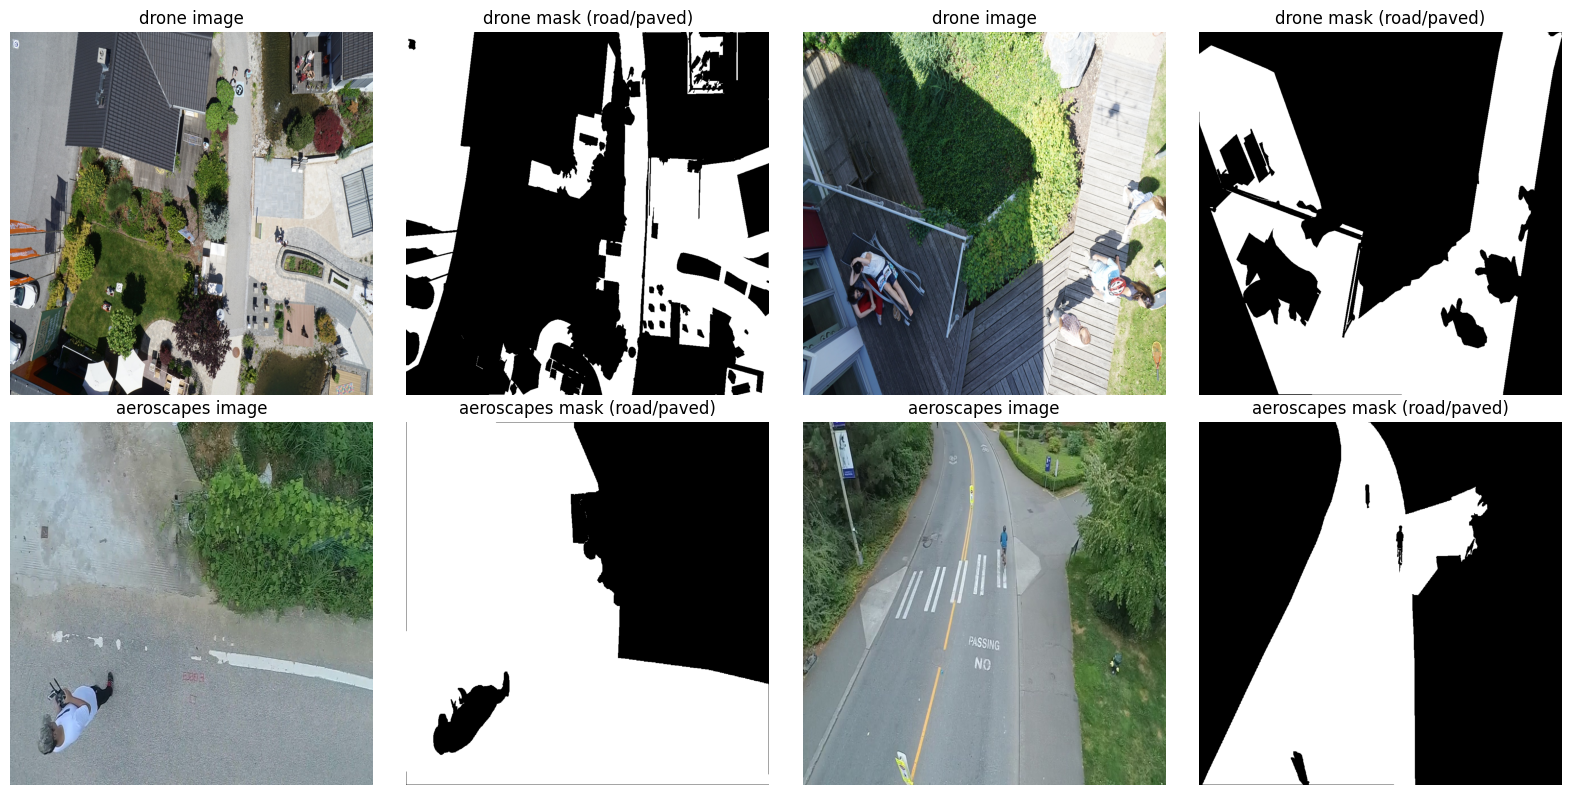

drone: mean road-pixel fraction across sample = 0.375 (min 0.109, max 0.870)
aeroscapes: mean road-pixel fraction across sample = 0.381 (min 0.000, max 0.867)


In [43]:
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np

OUT_DIR = "/kaggle/working/pretrain_data_stage3"
manifest = pd.read_csv(f"{OUT_DIR}/manifest.csv")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, source in enumerate(["drone", "aeroscapes"]):
    samples = manifest[manifest.source == source].sample(2, random_state=1)
    for j, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(f"{OUT_DIR}/{row.split}/images/{row['name']}.jpg")
        mask = Image.open(f"{OUT_DIR}/{row.split}/masks/{row['name']}.png")
        axes[i, j*2].imshow(img)
        axes[i, j*2].set_title(f"{source} image")
        axes[i, j*2].axis("off")
        axes[i, j*2+1].imshow(mask, cmap="gray")
        axes[i, j*2+1].set_title(f"{source} mask (road/paved)")
        axes[i, j*2+1].axis("off")
plt.tight_layout()
plt.show()

# Confirm mask pixel fraction isn't suspiciously 0% or 100% (would indicate a mapping bug)
for source in ["drone", "aeroscapes"]:
    fractions = []
    for _, row in manifest[manifest.source == source].sample(min(20, len(manifest[manifest.source==source])), random_state=1).iterrows():
        mask = np.array(Image.open(f"{OUT_DIR}/{row.split}/masks/{row['name']}.png"))
        fractions.append((mask > 0).mean())
    print(f"{source}: mean road-pixel fraction across sample = {np.mean(fractions):.3f} (min {np.min(fractions):.3f}, max {np.max(fractions):.3f})")

In [55]:
train_loader_stage3, val_loader_stage3, train_ds_stage3, val_ds_stage3=make_dataloaders(
    "/kaggle/working/pretrain_data_stage3/manifest.csv",
    "/kaggle/working/pretrain_data_stage3",
    source=None,
    crop_size=1024,
    batch_size=8
)
print(f"Stage 3 -  Train:{len(train_ds_stage3)}  Val: {len(val_ds_stage3)}")

Stage 3 -  Train:2981  Val: 688


In [ ]:
model_stage3=DualResNet(BasicBlock, [2,2,2,2], num_classes=2,
                       planes=32, spp_planes=128, head_planes=64, augment=False)
checkpoint=torch.load("/kaggle/input/datasets/aseedfaisal/latest-checkpoint/stage2_deepglobe_long_best.pth")
model_stage3.load_state_dict(checkpoint)
model_stage3=model_stage3.to(device)

val_loss_check, val_iou_check = validate(model_stage3, val_loader_dg, criterion, device)
mass_loss_check, mass_iou_check = validate(model_stage3, val_loader_mass, criterion, device)
print(f"DeepGlobe IoU: {val_iou_check:.4f} ")
print(f"Massachusetts IoU: {mass_iou_check:.4f} ")

In [ ]:
def run_training_stage3(model, train_loader, val_loader_stage3, val_loader_mass, val_loader_dg,
                       num_epochs, device, optimizer,
                       checkpoint_dir="/kaggle/working/checkpoints",
                       checkpoint_name="stage3_drone_aeroscapes"):
    os.makedirs(checkpoint_dir, exist_ok=True)
    scheduler=build_scheduler(optimizer, num_epochs=num_epochs, steps_per_epoch=len(train_loader))
    criterion=CombinedLoss()

    best_iou=0.0
    history=[]
    for epoch in range(num_epochs):
        print(f"\n=== Epoch {epoch+1}/{num_epochs}===")
        train_loss, train_ce, train_dice=train_one_epoch(
            model, train_loader, optimizer, scheduler, criterion, device
        )
        val_loss_s3, val_iou_s3=validate(model, val_loader_stage3, criterion, device)
        val_loss_mass, val_iou_mass=validate(model, val_loader_mass, criterion, device)
        val_loss_dg, val_iou_dg=validate(model, val_loader_dg, criterion, device)
        print(f"Train loss: {train_loss:.4f} (CE: {train_ce:.4f}, Dice: {train_dice:.4f})")
        print(f"[stage3]        Val loss: {val_loss_s3:.4f}   | Val IoU: {val_iou_s3:.4f}")
        print(f"[massachusetts] Val loss: {val_loss_mass:.4f} | Val IoU: {val_iou_mass:.4f}  <- forgetting check")
        print(f"[deepglobe]     Val loss: {val_loss_dg:.4f}   | Val IoU: {val_iou_dg:.4f}  <- forgetting check")

        history.append({
            "epoch": epoch + 1, "train_loss": train_loss, "train_ce": train_ce, "train_dice": train_dice,
            "stage3_val_loss": val_loss_s3, "stage3_val_iou": val_iou_s3,
            "mass_val_loss": val_loss_mass, "mass_val_iou": val_iou_mass,
            "dg_val_loss": val_loss_dg, "dg_val_iou": val_iou_dg,
        })

        if val_iou_s3 > best_iou:
            best_iou = val_iou_s3
            torch.save(model.state_dict(), f"{checkpoint_dir}/{checkpoint_name}_best.pth")
            print(f"   New best Stage 3 IoU ({val_iou_s3:.4f}) — checkpoint saved")

        torch.save(model.state_dict(), f"{checkpoint_dir}/{checkpoint_name}_last.pth")

    return history
        
        

In [ ]:
optimizer_stage3=build_optimizer(model_stage3, backbone_lr=2e-5, head_lr=2e-4, weight_decay=1e-4)
history_stage3=run_training_stage3(
    model_stage3, train_loader_stage3, val_loader_stage3, val_loader_mass, val_loader_dg,
    num_epochs=10, device=device, optimizer=optimizer_stage3,
    checkpoint_dir="/kaggle/working/checkpoints",
    checkpoint_name="stage3_drone_aeroscapes"    
)

**FINE-TUNING(Aeroscrapes+SemanticDroneDataset**

In [81]:
def train_one_epoch_finetune(model, loader, optimizer, scheduler, criterion, device, freeze_bn=False):
    model.train()
    if freeze_bn:
        unfreeze_prefixes=("layer3", "layer4", "layer5", 
                           "head.", "spp.", "final_layer.")
        for name, module in model.named_modules():
            if not(name.startswith(unfreeze_prefixes)):
               if isinstance(module, torch.nn.BatchNorm2d):
                   module.eval()   #Freeze the Batch Normalization Layers
    total_loss, total_ce, total_dice=0.0,0.0,0.0
    pbar=tqdm(loader, desc="train")
    for images, masks in pbar:
        images, masks=images.to(device), masks.to(device)
        optimizer.zero_grad()
        logits=model(images)
        if logits.shape[-2:] != masks.shape[-2:]:
            logits=F.interpolate(logits, size=masks.shape[-2:], mode="bilinear", align_corners=False)
        loss, ce_loss, dice_loss=criterion(logits, masks)
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()
        total_ce+=ce_loss.item()
        total_dice+=dice_loss.item()
        pbar.set_postfix(loss=loss.item())
    n=len(loader)
    return total_loss/n, total_ce/n, total_dice/n
    
        

In [ ]:
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimzer, mode="max", factor=0.5, patience=2, min_lr=1e-6
)

In [82]:
def run_training_stage3(model, train_loader, val_loader_stage3, val_loader_mass, val_loader_dg,
                         num_epochs, device, optimizer,
                         checkpoint_dir="/kaggle/working/checkpoints",
                         checkpoint_name="stage3_drone_aeroscapes"):
    os.makedirs(checkpoint_dir, exist_ok=True)
    scheduler = build_scheduler(optimizer, num_epochs=num_epochs, steps_per_epoch=len(train_loader))
    criterion = CombinedLoss()

    best_iou = 0.0
    history = []

    for epoch in range(num_epochs):
        print(f"\n=== Epoch {epoch+1}/{num_epochs} ===")
        train_loss, train_ce, train_dice = train_one_epoch_finetune(
            model, train_loader, optimizer, scheduler, criterion, device, freeze_bn=True
        )

        val_loss_s3, val_iou_s3 = validate(model, val_loader_stage3, criterion, device)
        val_loss_mass, val_iou_mass = validate(model, val_loader_mass, criterion, device)
        val_loss_dg, val_iou_dg = validate(model, val_loader_dg, criterion, device)
        print(f"Train loss: {train_loss:.4f} (CE: {train_ce:.4f}, Dice: {train_dice:.4f})")
        print(f"[stage3]        Val loss: {val_loss_s3:.4f}   | Val IoU: {val_iou_s3:.4f}")
        print(f"[massachusetts] Val loss: {val_loss_mass:.4f} | Val IoU: {val_iou_mass:.4f}  <- forgetting check")
        print(f"[deepglobe]     Val loss: {val_loss_dg:.4f}   | Val IoU: {val_iou_dg:.4f}  <- forgetting check")
        scheduler.item(val_iou_s3)
        history.append({
            "epoch": epoch + 1, "train_loss": train_loss, "train_ce": train_ce, "train_dice": train_dice,
            "stage3_val_loss": val_loss_s3, "stage3_val_iou": val_iou_s3,
            "mass_val_loss": val_loss_mass, "mass_val_iou": val_iou_mass,
            "dg_val_loss": val_loss_dg, "dg_val_iou": val_iou_dg,
        })

        if val_iou_s3 > best_iou:
            best_iou = val_iou_s3
            torch.save(model.state_dict(), f"{checkpoint_dir}/{checkpoint_name}_best.pth")
            print(f" New best Stage 3 IoU ({val_iou_s3:.4f}) — checkpoint saved")

        torch.save(model.state_dict(), f"{checkpoint_dir}/{checkpoint_name}_last.pth")

    return history

In [84]:
model_stage3=DualResNet(BasicBlock, [2,2,2,2], num_classes=2,
                       planes=32, spp_planes=128, head_planes=64, augment=False)
checkpoint=torch.load("/kaggle/input/datasets/aseedfaisal/latest-checkpoint/stage2_deepglobe_long_best.pth")
model_stage3.load_state_dict(checkpoint)
model_stage3=model_stage3.to(device)



In [60]:
val_loss_check, val_iou_check = validate(model_stage3, val_loader_dg, criterion, device)
mass_loss_check, mass_iou_check = validate(model_stage3, val_loader_mass, criterion, device)
print(f"DeepGlobe IoU: {val_iou_check:.4f} (expect ~0.6134)")
print(f"Massachusetts IoU: {mass_iou_check:.4f} (expect ~0.33-0.35)")



DeepGlobe IoU: 0.6157 (expect ~0.6134)
Massachusetts IoU: 0.3460 (expect ~0.33-0.35)


In [85]:
optimizer_stage3 = build_optimizer(model_stage3, backbone_lr=1e-5, head_lr=1e-4, weight_decay=1e-4)


In [87]:
def freeze_backbone(model):
    for name, param in model.named_parameters():
        if name.startswith("spp.") or name.startswith("final_layer.") or name.startswith("head."):
            param.requires_grad=True
        else:
            param.requires_grad=False



In [86]:
model_stage3=DualResNet(BasicBlock, [2,2,2,2], num_classes=2,
                       planes=32, spp_planes=128, head_planes=64, augment=False)
checkpoint=torch.load("/kaggle/input/datasets/aseedfaisal/latest-checkpoint/stage2_deepglobe_long_best.pth")
model_stage3.load_state_dict(checkpoint)
model_stage3=model_stage3.to(device)
freeze_backbone(model_stage3)


In [88]:
trainable = sum(p.numel() for p in model_stage3.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model_stage3.parameters() if not p.requires_grad)
print(f"Trainable: {trainable/1e6:.2f}M | Frozen: {frozen/1e6:.2f}M")

Trainable: 1.15M | Frozen: 4.55M


In [72]:
class ReplayRoadSegDataset(Dataset):
    def __init__(self, manifest_df, split, transform=None):
        self.df = manifest_df[manifest_df.split == split].reset_index(drop=True)
        self.split = split
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = f"{row['root_dir']}/{self.split}/images/{row['name']}.jpg"
        mask_path = f"{row['root_dir']}/{self.split}/masks/{row['name']}.png"

        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path).convert("L"))
        mask = (mask > 127).astype(np.int64)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"].long()

        return image, mask

In [73]:
import pandas as pd

manifest_stage3 = pd.read_csv("/kaggle/working/pretrain_data_stage3/manifest.csv")
manifest_stage3["root_dir"] = "/kaggle/working/pretrain_data_stage3"

manifest_old = pd.read_csv("/kaggle/working/pretrain_data/manifest.csv")
manifest_old["root_dir"] = "/kaggle/working/pretrain_data"

combined_train = pd.concat([
    manifest_stage3[manifest_stage3.split == "train"],
    manifest_old[manifest_old.split == "train"]
], ignore_index=True)

# --- Replay weighting: Stage 3 dominant, old data as a minority slice ---
REPLAY_FRACTION = 0.175  # ~17.5% of each epoch's draws come from Mass+DeepGlobe

n_stage3 = (combined_train.root_dir == "/kaggle/working/pretrain_data_stage3").sum()
n_old = (combined_train.root_dir == "/kaggle/working/pretrain_data").sum()

# weight per-sample such that total probability mass for "old" group == REPLAY_FRACTION
weight_stage3 = (1 - REPLAY_FRACTION) / n_stage3
weight_old = REPLAY_FRACTION / n_old

combined_train["sample_weight"] = combined_train.root_dir.map({
    "/kaggle/working/pretrain_data_stage3": weight_stage3,
    "/kaggle/working/pretrain_data": weight_old
})

print(f"Stage3 samples: {n_stage3} (weight each: {weight_stage3:.2e})")
print(f"Old samples: {n_old} (weight each: {weight_old:.2e})")
print(f"Sanity check — weights sum to 1.0: {combined_train.sample_weight.sum():.4f}")

Stage3 samples: 2981 (weight each: 2.77e-04)
Old samples: 6711 (weight each: 2.61e-05)
Sanity check — weights sum to 1.0: 1.0000


In [74]:
from torch.utils.data import WeightedRandomSampler

train_ds_replay = ReplayRoadSegDataset(combined_train, split="train", transform=get_train_transforms())

sampler = WeightedRandomSampler(
    weights=combined_train.sample_weight.values,
    num_samples=len(combined_train[combined_train.root_dir == "/kaggle/working/pretrain_data_stage3"]),
    replacement=True
)

train_loader_replay = DataLoader(
    train_ds_replay, batch_size=8, sampler=sampler,
    num_workers=4, pin_memory=True, drop_last=True
)

print(f"Replay train loader: {len(train_loader_replay)} batches/epoch "
      f"(~{len(train_loader_replay)*8} samples, {REPLAY_FRACTION*100:.0f}% target replay)")

Replay train loader: 372 batches/epoch (~2976 samples, 18% target replay)


In [75]:
sample_indices = list(sampler)
sampled_roots = combined_train.iloc[sample_indices].root_dir
actual_replay_fraction = (sampled_roots == "/kaggle/working/pretrain_data").mean()
print(f"Actual replay fraction in this epoch's draws: {actual_replay_fraction:.3f} (target: {REPLAY_FRACTION})")

Actual replay fraction in this epoch's draws: 0.175 (target: 0.175)


In [77]:
model_stage3=DualResNet(BasicBlock, [2,2,2,2], num_classes=2,
                       planes=32, spp_planes=128, head_planes=64, augment=False)
checkpoint=torch.load("/kaggle/input/datasets/aseedfaisal/latest-checkpoint/stage2_deepglobe_long_best.pth")
model_stage3.load_state_dict(checkpoint)
model_stage3=model_stage3.to(device)
freeze_backbone(model_stage3)


In [91]:
model_stage3 = DualResNet(BasicBlock, [2, 2, 2, 2], num_classes=2,
                           planes=32, spp_planes=128, head_planes=64, augment=False)
checkpoint = torch.load("/kaggle/input/datasets/aseedfaisal/latest-checkpoint/stage2_deepglobe_long_best.pth", map_location="cpu")
model_stage3.load_state_dict(checkpoint)
model_stage3 = model_stage3.to(device)

# Confirm clean state before doing anything else
val_loss_check, val_iou_check = validate(model_stage3, val_loader_dg, criterion, device)
mass_loss_check, mass_iou_check = validate(model_stage3, val_loader_mass, criterion, device)
print(f"DeepGlobe IoU: {val_iou_check:.4f} (expect ~0.6134)")
print(f"Massachusetts IoU: {mass_iou_check:.4f} (expect ~0.33-0.35)")

freeze_backbone(model_stage3)

trainable = sum(p.numel() for p in model_stage3.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model_stage3.parameters() if not p.requires_grad)
print(f"Trainable: {trainable/1e6:.2f}M | Frozen: {frozen/1e6:.2f}M")

optimizer_stage3 = torch.optim.AdamW(
    [p for p in model_stage3.parameters() if p.requires_grad],
    lr=2e-4, weight_decay=1e-4
)

DeepGlobe IoU: 0.6157 (expect ~0.6134)
Massachusetts IoU: 0.3460 (expect ~0.33-0.35)
Trainable: 1.15M | Frozen: 4.55M


In [92]:
history_stage3_replay = run_training_stage3(
    model_stage3, train_loader_replay, val_loader_stage3, val_loader_mass, val_loader_dg,
    num_epochs=10, device=device,
    optimizer=optimizer_stage3,
    checkpoint_dir="/kaggle/working/checkpoints",
    checkpoint_name="stage3_drone_aeroscapes_replay"
)


=== Epoch 1/10 ===


train: 100%|██████████| 372/372 [01:34<00:00,  3.92it/s, loss=0.416]


Train loss: 1.1313 (CE: 1.5754, Dice: 0.6871)
[stage3]        Val loss: 0.5268   | Val IoU: 0.4492
[massachusetts] Val loss: 0.4793 | Val IoU: 0.3077  <- forgetting check
[deepglobe]     Val loss: 0.3144   | Val IoU: 0.3964  <- forgetting check
 New best Stage 3 IoU (0.4492) — checkpoint saved

=== Epoch 2/10 ===


train: 100%|██████████| 372/372 [01:34<00:00,  3.94it/s, loss=0.329]


Train loss: 0.4484 (CE: 0.4112, Dice: 0.4856)
[stage3]        Val loss: 0.3889   | Val IoU: 0.5764
[massachusetts] Val loss: 0.4664 | Val IoU: 0.2929  <- forgetting check
[deepglobe]     Val loss: 0.3393   | Val IoU: 0.4005  <- forgetting check
 New best Stage 3 IoU (0.5764) — checkpoint saved

=== Epoch 3/10 ===


...

Train loss: 0.2725 (CE: 0.2098, Dice: 0.3352)
[stage3]        Val loss: 0.3404   | Val IoU: 0.6544
[massachusetts] Val loss: 0.4237 | Val IoU: 0.3188  <- forgetting check
[deepglobe]     Val loss: 0.2488   | Val IoU: 0.4832  <- forgetting check

=== Epoch 9/10 ===


train: 100%|██████████| 372/372 [01:33<00:00,  3.98it/s, loss=0.315]


Train loss: 0.2731 (CE: 0.2027, Dice: 0.3434)
[stage3]        Val loss: 0.3353   | Val IoU: 0.6476
[massachusetts] Val loss: 0.4267 | Val IoU: 0.3030  <- forgetting check
[deepglobe]     Val loss: 0.2409   | Val IoU: 0.4933  <- forgetting check

=== Epoch 10/10 ===


train: 100%|██████████| 372/372 [01:35<00:00,  3.90it/s, loss=0.327]


Train loss: 0.2613 (CE: 0.1962, Dice: 0.3264)
[stage3]        Val loss: 0.3278   | Val IoU: 0.6661
[massachusetts] Val loss: 0.4177 | Val IoU: 0.3047  <- forgetting check
[deepglobe]     Val loss: 0.2457   | Val IoU: 0.4928  <- forgetting check


In [97]:
import zipfile

files_to_save = [
    "/kaggle/working/checkpoints/stage3_drone_aeroscapes_replay_best.pth",
    "/kaggle/working/checkpoints/stage3_drone_aeroscapes_replay_last.pth",
]

with zipfile.ZipFile("/kaggle/working/latest_checkpoints.zip", "w") as z:
    for file in files_to_save:
        z.write(file, arcname=file.split("/")[-1])

print("Created:", "/kaggle/working/latest_checkpoints.zip")

Created: /kaggle/working/latest_checkpoints.zip
